# Project : Image Denoising Using Autoencoder on MNIST

## Problem Statement


The objective of this project is to build a **Denoising Autoencoder** using the MNIST handwritten digit dataset. A denoising autoencoder is a type of neural network that learns to reconstruct clean images from noisy inputs. In this project, artificial Gaussian noise is added to the original MNIST images to create noisy versions. The autoencoder is then trained using the noisy images as inputs and the corresponding clean images as target outputs.

The model consists of an **encoder**, which compresses the input image into a lower-dimensional latent representation, and a **decoder**, which reconstructs the original image from this representation. The performance of the model is evaluated by visually comparing the **original**, **noisy**, and **reconstructed (denoised)** images, along with monitoring the training and validation loss during the learning process.

The primary goal is to demonstrate how deep learning techniques can effectively remove noise from images while preserving the important structural features of handwritten digits.

# Step 1: Import Required Libraries

The required libraries are imported for image processing, numerical computation, visualization, deep learning model development, and evaluation.

In [27]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model

# Step 2: Load the dataset


The provided MNIST dataset contains grayscale handwritten digit images organized into training and testing folders. Each folder contains separate subfolders for digits from 0 to 9.

The dataset is extracted and a custom image loading function is used to read the PNG images and their corresponding labels.

In [28]:
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


# Step 3: Load Images

In [29]:
def load_images(folder):

    images = []
    labels = []

    for label in sorted(os.listdir(folder)):

        label_path = os.path.join(folder, label)

        if os.path.isdir(label_path):

            for image_name in os.listdir(label_path):

                image_path = os.path.join(label_path, image_name)

                image = Image.open(image_path).convert("L")

                image = np.array(image)

                images.append(image)

                labels.append(int(label))

    return np.array(images), np.array(labels)

# Step 4: Load Training Dataset

In [30]:
train_folder = os.path.join(extract_path, "mnist_png", "training")

x_train, y_train = load_images(train_folder)

print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


# Step 5: Load Testing Dataset

In [31]:
test_folder = os.path.join(extract_path, "mnist_png", "testing")

x_test, y_test = load_images(test_folder)

print(x_test.shape)
print(y_test.shape)

(10000, 28, 28)
(10000,)


# Step 6: Display Sample Images

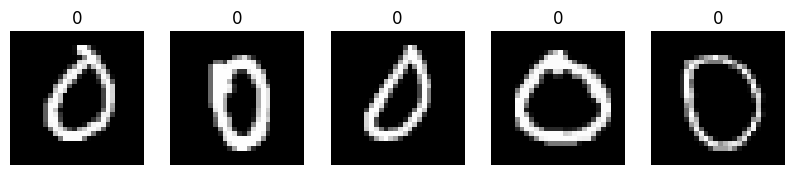

In [32]:
plt.figure(figsize=(10,3))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(x_train[i], cmap="gray")

    plt.title(y_train[i])

    plt.axis("off")

plt.show()

# Step 7: Normalize Images

In [33]:
x_train = x_train.astype("float32") / 255.0

x_test = x_test.astype("float32") / 255.0

# Step 8: Reshape Images

In [34]:
x_train = np.expand_dims(x_train, axis=-1)

x_test = np.expand_dims(x_test, axis=-1)

print(x_train.shape)

print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


# Step 9: Add Gaussian Noise

In [35]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)

x_test_noisy = np.clip(x_test_noisy,0.,1.)

# Step 10: Display Noisy Images

Sample original images are compared with their corresponding noisy versions to visualize the effect of artificial Gaussian noise on the MNIST handwritten digits.

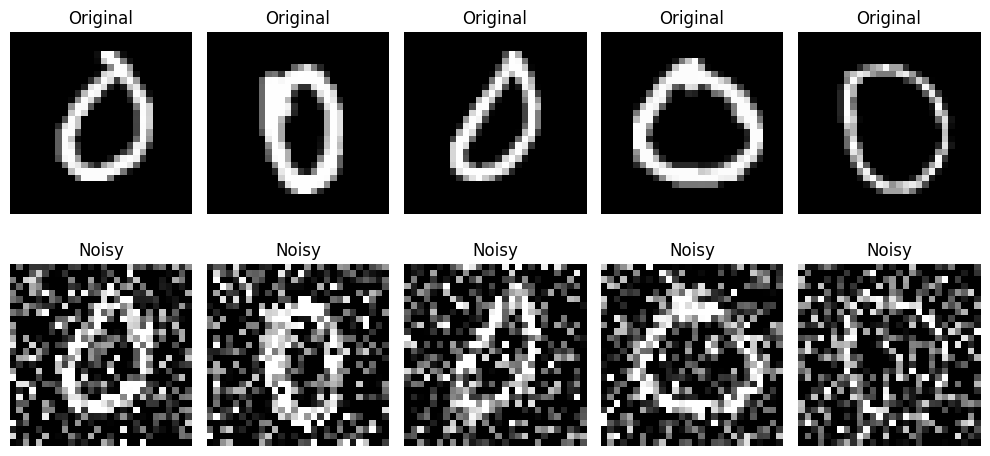

In [36]:
plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(2,5,i+1)

    plt.imshow(x_train[i].squeeze(), cmap="gray")

    plt.axis("off")

    plt.title("Original")

    plt.subplot(2,5,i+6)

    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")

    plt.axis("off")

    plt.title("Noisy")

plt.tight_layout()

plt.show()

# Step 11: Build Autoencoder

A Convolutional Denoising Autoencoder is developed using separate encoder and decoder components.

The encoder uses convolutional and max-pooling layers to extract important spatial features and compress the input image representation. The decoder uses convolutional and upsampling layers to reconstruct a cleaner image from the encoded features.

Convolutional layers are suitable for image denoising because they can learn spatial patterns such as edges, curves, and handwritten digit strokes.

In [37]:
input_image = layers.Input(shape=(28,28,1))

**Encoder**

In [38]:
x = layers.Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"
)(input_image)

x = layers.MaxPooling2D(
    (2,2),
    padding="same"
)(x)

x = layers.Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)

encoded = layers.MaxPooling2D(
    (2,2),
    padding="same"
)(x)

# Decoder

In [39]:
x = layers.Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(encoded)

x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)

# Step 12: Create Model

In [40]:
autoencoder = Model(input_image, decoded)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

# Step 13: Compile Model

In [41]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# Step 14: Train Model

In [42]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy,x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.1622 - val_loss: 0.1139
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1104 - val_loss: 0.1056
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1050 - val_loss: 0.1025
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1025 - val_loss: 0.1005
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1008 - val_loss: 0.0996
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0995 - val_loss: 0.0985
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0986 - val_loss: 0.0976
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0979 - val_loss: 0.0967
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0972 - val_loss: 0.0962
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0967 - val_loss: 0.0958


# Step 15: Predict Denoised Images

The trained Autoencoder is used to process the noisy test images. The reconstructed outputs generated by the model represent the denoised images.

In [43]:
decoded_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


# Step 16: Visualize Results

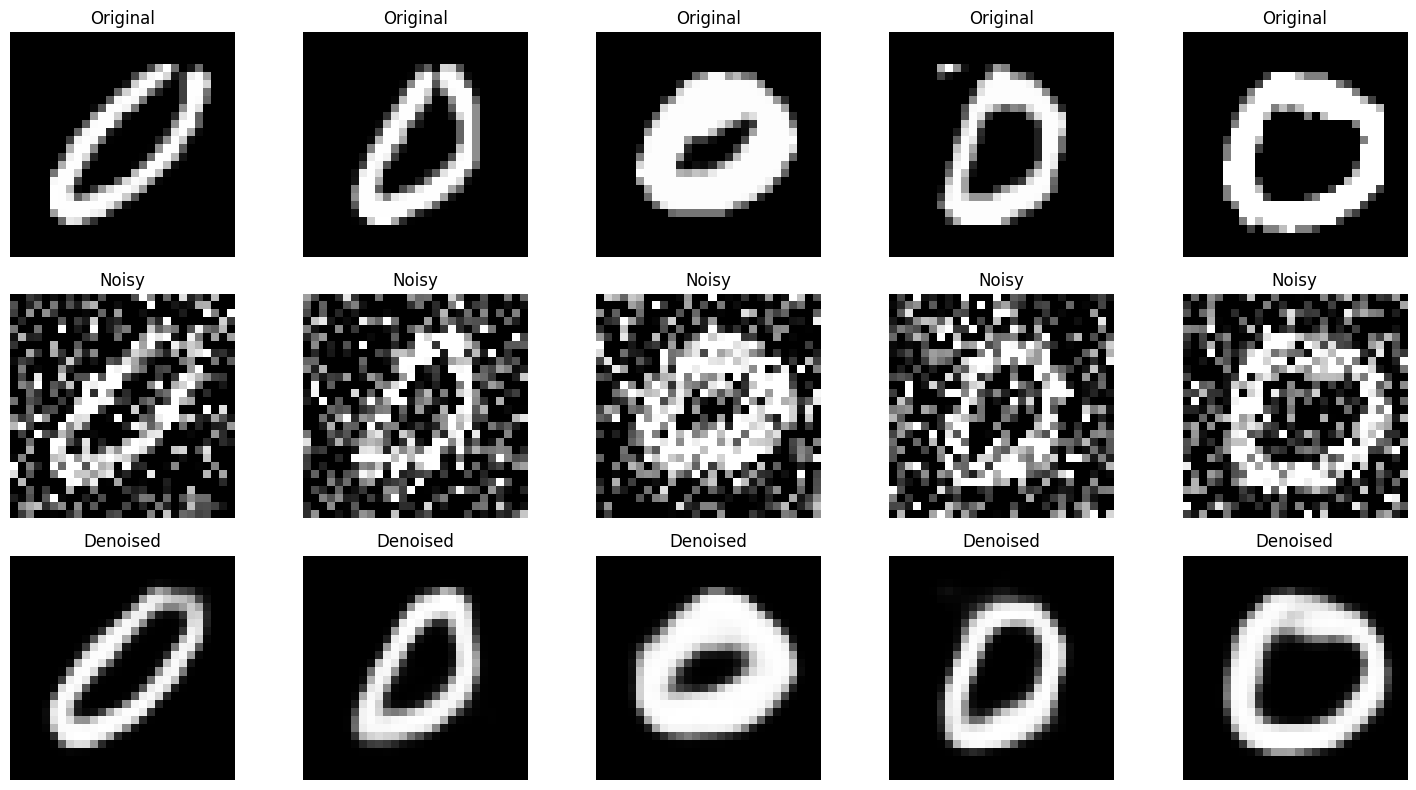

In [44]:
n = 5

plt.figure(figsize=(15,8))

for i in range(n):

    # Original
    plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_images[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()

plt.show()

# Step 17: Plot Loss Graph

The training and validation loss values are plotted across epochs to analyze the learning behavior of the Autoencoder. A decreasing reconstruction loss indicates that the model is improving its ability to reconstruct clean images from noisy inputs.

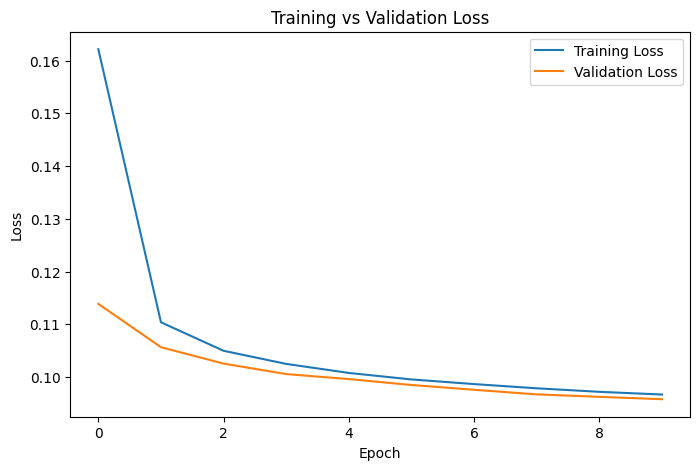

In [45]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

# Step 18: Observations
1. The denoising autoencoder successfully learned to reconstruct clean handwritten digits from noisy images.

2. The reconstructed images retained the overall digit structure while removing most of the Gaussian noise.

3. Training and validation loss consistently decreased, indicating effective learning.

4. Some fine details were slightly blurred due to the compression in the latent space.

5. Higher noise levels would make reconstruction more challenging and may require a deeper network or more training epochs.


# Challenges

1. Selecting an appropriate noise factor was important because excessive noise made reconstruction difficult.

2. The reconstructed images were slightly blurred due to compression in the latent space.

3. Increasing model depth improves reconstruction quality but also increases training time.

4. Balancing denoising performance and preservation of fine image details was challenging.

# Innovation

*   Use BatchNormalization
*   Use PSNR and SSIM as evaluation metrics
*   Train for more epochs (20–30)
*   Compare noise factors 0.2, 0.5 and 0.7



### Conclusion

Overall, the Convolutional Denoising Autoencoder effectively removed artificial noise while maintaining recognizable handwritten digit structures. The visual comparison of original, noisy, and denoised images demonstrated successful noise reduction.

The lower MSE and higher PSNR values of the denoised images provided quantitative evidence of improved reconstruction quality. This project demonstrates the effectiveness of Convolutional Autoencoders for image denoising, reconstruction, and feature learning.